# Pokemon (Dark / Ghost) — exploratory analysis

Data file: **`pokemon_dark_ghost_gen1_4.csv`** in the same folder as this notebook (`week5/`).

**If code cells do not run:** choose a **Python kernel** for the notebook (kernel picker in the notebook toolbar). Run the **first code cell** before the others so `df` exists. You need **`pandas`** and **`matplotlib`** installed in that environment (`pip install pandas matplotlib`).

**If cells run but you see no output:** click the **thin bar or chevron directly under the cell** to expand the output area (outputs are sometimes collapsed). Try **Notebook: Clear All Outputs**, then **Restart Kernel**, then run the first cell again. The code below also uses `print` / `display` / `plt.show()` so results are easier for the editor to show.

In [1]:
%matplotlib inline
import io
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# We are asking: which copy of the CSV is the real one on this machine, and how big is the table we will analyze?
# The printed path and shape answer: we are using that exact file, and every later conclusion applies to that many Pokémon rows and that many variables (columns).

# Jupyter's working directory is often the repo root, not week5 — try several locations
_csv = "pokemon_dark_ghost_gen1_4.csv"
_candidates = [
    Path(_csv),
    Path("week5") / _csv,
    Path("../week5") / _csv,
    Path("../week4") / _csv,
]
path = next((p.resolve() for p in _candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        f"Could not find {_csv}. Tried: {[str(p) for p in _candidates]}"
    )

# read_csv turns the file into one DataFrame; shape is our sample size for all summaries below
df = pd.read_csv(path)
print("Loaded:", path)
print("Shape (rows, columns):", df.shape)

Loaded: C:\Users\stuti\HCDE530\week5\pokemon_dark_ghost_gen1_4.csv
Shape (rows, columns): (55, 13)


## 1. What does the data look like?

Use `head()` for a quick peek at rows and columns, and `info()` for dtypes and non-null counts.

In [2]:
# We are asking: what do real rows look like—column names, example values, and rough scale of stats?
# head()'s answer means: each row is one species/form with IDs, a pipe-separated typings string, and numeric battle stats; we are sanity-checking structure before trusting aggregates.

display(df.head())

,id,species_id,name,types,base_experience,height,weight,hp,attack,defense,special_attack,special_defense,speed
0,10007,487,giratina-origin,ghost|dragon,340,69,6500,150,120,100,120,100,90
1,10038,94,gengar-mega,ghost|poison,270,14,405,60,65,80,170,95,130
2,10041,130,gyarados-mega,water|dark,224,65,3050,95,155,109,70,130,81
3,10048,229,houndoom-mega,dark|fire,210,19,495,75,90,90,140,90,115
4,10049,248,tyranitar-mega,rock|dark,315,25,2550,100,164,150,95,120,71


In [3]:
# We are asking: are dtypes sensible, and are any columns secretly incomplete (nulls) before we filter or average?
# info()'s answer means: we see 55 non-null entries per column here—so this slice is fully populated in every field, mostly integers plus text for name/types; memory use is tiny, so performance is not a worry.

buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               55 non-null     int64
 1   species_id       55 non-null     int64
 2   name             55 non-null     str  
 3   types            55 non-null     str  
 4   base_experience  55 non-null     int64
 5   height           55 non-null     int64
 6   weight           55 non-null     int64
 7   hp               55 non-null     int64
 8   attack           55 non-null     int64
 9   defense          55 non-null     int64
 10  special_attack   55 non-null     int64
 11  special_defense  55 non-null     int64
 12  speed            55 non-null     int64
dtypes: int64(11), str(2)
memory usage: 5.7 KB



## 2. Distribution of `attack` and `special_attack`

Summary stats plus histograms give a rough picture of how offensive stats spread in this slice.

In [9]:
# We are asking: how do physical attack vs special attack spread—typical values, spread, and extremes—in this Dark/Ghost–related slice?
# describe()'s answer means: means/medians tell which stat tends higher overall; std and min/max show variability and how extreme glass cannons or walls can get in this dataset.

display(df[["attack", "special_attack"]].describe())

# --- Interpretation (plain read of the table above) ---
# Mean attack (~90) is higher than mean special_attack (~79): this slice leans a bit toward physical hitters overall.
# Medians (84 vs 75) say the same for the "typical" row, not just outliers.
# Standard deviations (~33 on each) show both stats are spread wide: the roster mixes weak forms, walls, and glass cannons rather than one tight band.
# Max special_attack (170) slightly exceeds max attack (165), so standout special sweepers (e.g. Mega Gengar) exist alongside very high physical attackers.

,attack,special_attack
count,55.000000,55.000000
mean,89.672727,78.618182
std,33.060021,34.461192
min,30.000000,25.000000
25%,65.000000,52.500000
50%,84.000000,75.000000
75%,115.000000,97.500000
max,165.000000,170.000000


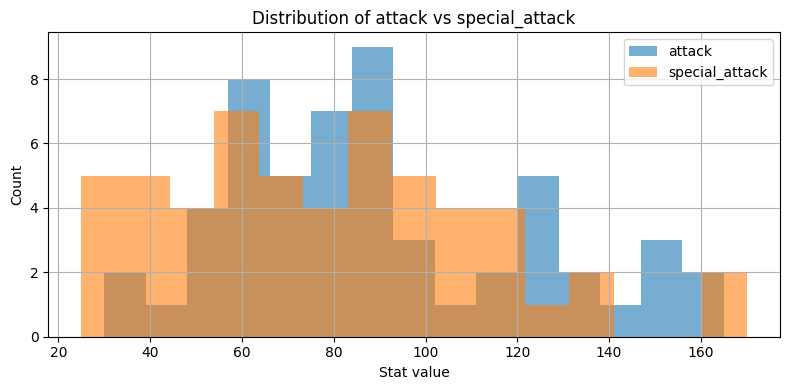

In [5]:
# We are asking: where do species pile up on the attack vs special_attack scales—similar peaks or different populations?
# The histograms answer: overlap shows whether this group skews toward brawlers, special sweepers, or balanced builds compared to each other.

fig, ax = plt.subplots(figsize=(8, 4))
df["attack"].hist(bins=15, alpha=0.6, label="attack", ax=ax)
df["special_attack"].hist(bins=15, alpha=0.6, label="special_attack", ax=ax)
ax.set_xlabel("Stat value")
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Distribution of attack vs special_attack")
plt.tight_layout()
plt.show()

# --- Interpretation (plain read of the histogram above) ---
# Where the two colors overlap, many species share similar values on both axes; where one color dominates a bin, more rows fall in that stat bucket for that stat alone.
# You are comparing the shape of the two distributions, not a single winner: both curves stretching to high values means this dataset includes elite physical and elite special threats.

## 3. Meaningful subset: **Dark** and **Ghost** (both in `types`), plus `base_experience`

The `types` column uses `|` between two typings when present. We keep rows whose typings include **both** `dark` and `ghost` (e.g. `dark|ghost`, `ghost|dark`). Then we inspect that subset, including `base_experience`.

In [8]:
# We are asking: among all rows here, which species are dual-typed with BOTH Dark and Ghost in the typings string?
# The filtered table answers: only those rare forms matter for this question; their base_experience and offensive stats describe how that tiny subgroup compares to the full 55-row set.

both_dark_ghost = df[
    df["types"].str.contains("dark", case=False, na=False)
    & df["types"].str.contains("ghost", case=False, na=False)
]
display(
    both_dark_ghost[
        ["name", "types", "base_experience", "attack", "special_attack"]
    ]
)

# --- Interpretation (plain read of the filtered table above) ---
# Only three rows have both Dark and Ghost in typings, so dual dark|ghost is rare in this slice compared to all 55 rows.
# They are special forms (mega / variant) more than a big natural family; do not generalize these three to "all Dark" or "all Ghost" Pokémon in the file.
# Base Sableye is the weakest attacker of the three; Mega Sableye balances offenses; Absol-Mega-Z is skewed to huge physical attack with moderate special_attack and base_experience 0 (likely bad or placeholder data in the source).


,name,types,base_experience,attack,special_attack
7,sableye-mega,dark|ghost,168,85,85
26,absol-mega-z,dark|ghost,0,154,75
40,sableye,dark|ghost,133,75,65


In [13]:
# We are asking: for only Dark+Ghost dual types, how does base_experience vary (reward / "leveling weight" in the games)?
# describe()'s answer means: central tendency and spread for that subgroup; watch for oddities like a zero—meaning one form may be flagged or missing XP in the source data, which affects how we interpret “typical” for that row.

display(both_dark_ghost["base_experience"].describe())

# --- Interpretation (plain read of the describe output above) ---
# With only three values, one zero (Absol-Mega-Z) drags the mean (~100) below what you might expect from the other two (133 and 168); the median (133) is a safer "typical" reward than the mean here.
# The large standard deviation is mostly a small-sample artifact plus that zero, not proof that dual Dark/Ghost forms are wildly inconsistent in the real games.


count      3.000000
mean     100.333333
std       88.635960
min        0.000000
25%       66.500000
50%      133.000000
75%      150.500000
max      168.000000
Name: base_experience, dtype: float64

## 4. Group by a category — **Poison** in typings vs not, average `special_attack`

`base_experience` is numeric in this file, so “base_experience=poison” is interpreted as a **type** question: does the species typings include **poison**? We group by that yes/no category and take the mean `special_attack`.

In [7]:
# We are asking: if we split species by whether typings include Poison or not, does average special_attack differ between the two groups?
# groupby + mean answers: the table compares average special offensive power; count tells how many species sit in each bucket—small poison counts mean the difference is suggestive, not statistically airtight from this table alone.

_poison_summary = (
    df.assign(
        poison_in_types=lambda d: d["types"]
        .str.contains("poison", case=False, na=False)
        .map({True: "types include poison", False: "no poison type"})
    )
    .groupby("poison_in_types", observed=True)["special_attack"]
    .agg(["mean", "count"])
    .round(2)
)
display(_poison_summary)

# --- Interpretation (plain read of the grouped means above) ---
# Species whose typings include Poison average about 83.5 special_attack versus about 78 without Poison—a modest gap of roughly five points on this scale.
# Only six rows have Poison versus forty-nine without, so one or two megas (e.g. Gengar line) can move the poison-group mean a lot; treat the gap as suggestive, not proof of a universal rule.
# Story-wise, the poison-typed rows here are often ghost/poison or poison/dark lines that lean on special offense more than the non-poison average in this particular slice.


,mean,count
poison_in_types,,
no poison type,78.02,49
types include poison,83.50,6


## 5. Missing values — where are they?

Per-column counts of nulls; all columns complete if every count is 0.

In [10]:
# We are asking: column by column, how many missing values hide in this dataset?
# isnull().sum() answers: any non-zero count would mean we lose or distort rows in filters and means for that column; sorting puts the worst gaps on top if they exist.

display(df.isnull().sum().sort_values(ascending=False))

id                 0
species_id         0
name               0
types              0
base_experience    0
height             0
weight             0
hp                 0
attack             0
defense            0
special_attack     0
special_defense    0
speed              0
dtype: int64

In [11]:
# We are asking: is there any column that still needs imputation or dropping before we trust the notebook end-to-end?
# The branch answers: either we print reassurance (no nulls anywhere) or we list only the broken columns so we know exactly what to fix in the data.

incomplete = df.isnull().sum()
miss = incomplete[incomplete > 0]
if miss.empty:
    print("No incomplete columns (no nulls in any column).")
else:
    display(miss)

No incomplete columns (no nulls in any column).
